In [1]:
import os
import json
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pycocotools.coco import COCO
from tqdm import tqdm

In [6]:
def load_coco(json_path):
    """
    Load COCO annotations from the given JSON file path.
    """
    print(f"Loading COCO annotations from: {json_path}")
    coco = COCO(json_path)
    return coco


def extract_mask_stats(coco):
    """
    Extracts statistics per semantic class from COCO-formatted segmentation annotations.
    Returns:
        class_pixel_counts: total mask area per class
        relative_area_percent: list of % mask areas (w.r.t. image size) per class
        absolute_area_pixels: list of mask pixel counts per annotation per class
    """
    img_id_to_info = {img['id']: img for img in coco.dataset['images']}
    class_pixel_counts = defaultdict(int)
    relative_area_percent = defaultdict(list)
    absolute_area_pixels = defaultdict(list)

    for ann in tqdm(coco.dataset['annotations'], desc="Processing annotations"):
        cat_id = ann['category_id']
        image_info = img_id_to_info[ann['image_id']]
        img_area = image_info['width'] * image_info['height']

        mask = coco.annToMask(ann)
        mask_area = mask.sum()

        class_pixel_counts[cat_id] += mask_area
        relative_area_percent[cat_id].append((mask_area / img_area) * 100)
        absolute_area_pixels[cat_id].append(mask_area)

    return class_pixel_counts, relative_area_percent, absolute_area_pixels


def plot_class_distribution(class_pixel_counts, cat_id_to_name):
    """
    Plot total mask pixel distribution per class.
    """
    class_names = [cat_id_to_name[cid] for cid in class_pixel_counts.keys()]
    pixels = [class_pixel_counts[cid] for cid in class_pixel_counts.keys()]
    plt.figure(figsize=(10, 5))
    sns.barplot(x=class_names, y=pixels)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Total Mask Pixels")
    plt.title("Semantic Class Distribution")
    plt.tight_layout()
    plt.show()


def plot_box(data_dict, cat_id_to_name, ylabel, title):
    """
    Generic function to create a box plot from a dictionary of lists keyed by class ID.
    """
    data = []
    labels = []
    for cid, values in data_dict.items():
        data.append(values)
        labels.append(cat_id_to_name[cid])

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=data)
    plt.xticks(ticks=range(len(labels)), labels=labels, rotation=45, ha='right')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()


def analyze_and_plot_coco_segmentation(json_path):
    """
    Master function to load COCO data, extract stats, and plot all three visualizations.
    """
    coco = load_coco(json_path)
    class_pixel_counts, relative_area_percent, absolute_area_pixels = extract_mask_stats(coco)
    cat_id_to_name = {cat['id']: cat['name'] for cat in coco.loadCats(coco.getCatIds())}

    # Plot 1: Total pixel distribution per class
    plot_class_distribution(class_pixel_counts, cat_id_to_name)

    # Plot 2: Box plot of relative mask area (% of image)
    plot_box(relative_area_percent, cat_id_to_name,
             ylabel="Mask Area (% of Image Area)",
             title="Relative Mask Area Distribution (Per Image)")

    # Plot 3: Box plot of absolute mask pixel counts
    plot_box(absolute_area_pixels, cat_id_to_name,
             ylabel="Mask Area (Pixels)",
             title="Absolute Mask Area Distribution (Per Image)")

Loading COCO annotations from: /home/akshay/dgx-code/ImageSegmentation/data/car-parts-and-car-damages/Car_damages_dataset/split_annotations/train.json
loading annotations into memory...
Done (t=0.23s)
creating index...
index created!


Processing annotations: 100%|██████████| 7318/7318 [00:06<00:00, 1205.15it/s]


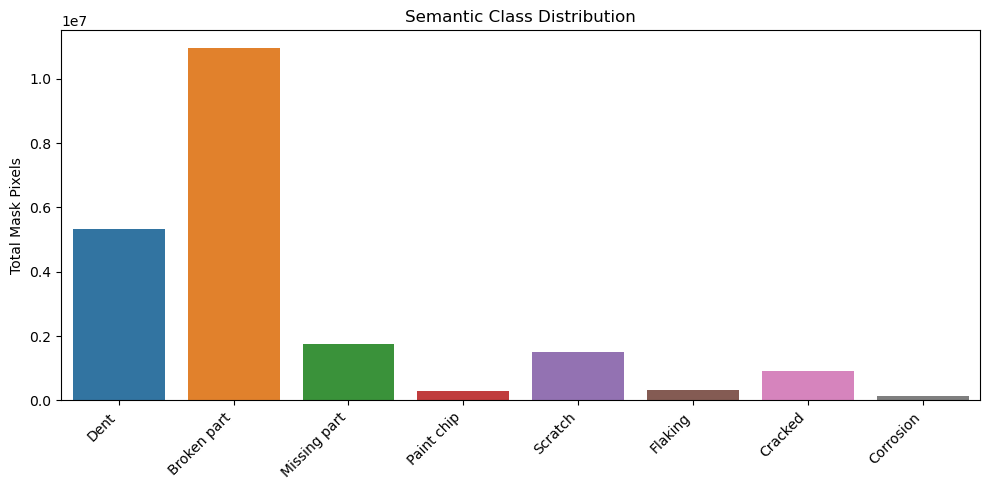

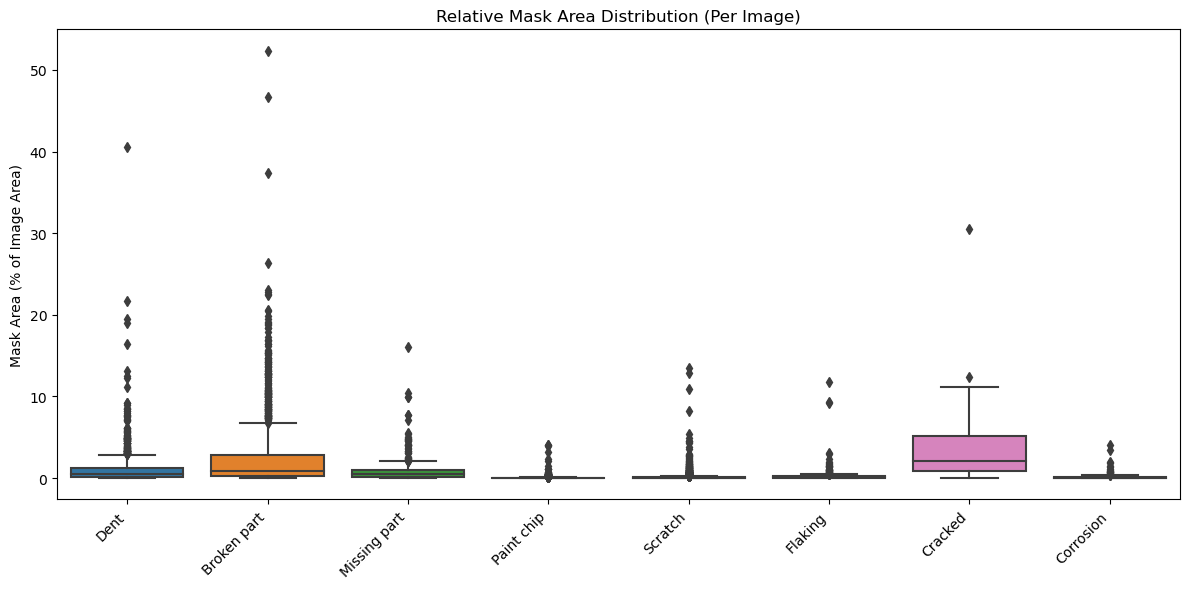

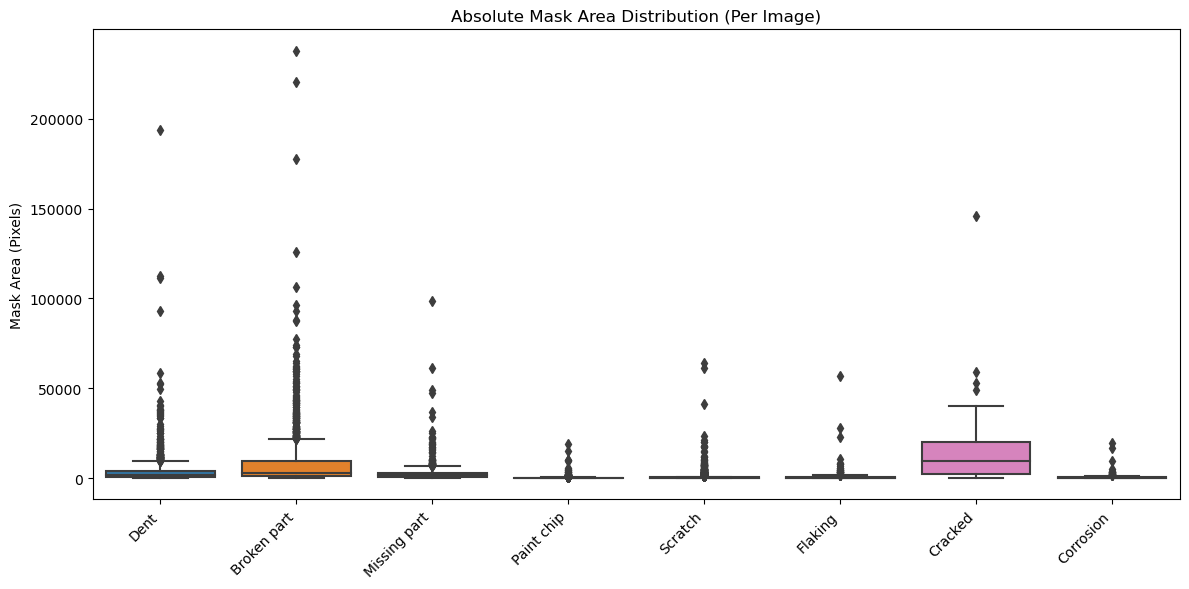

In [11]:
analyze_and_plot_coco_segmentation("/home/akshay/dgx-code/ImageSegmentation/data/car-parts-and-car-damages/Car_damages_dataset/split_annotations/train.json")

Loading COCO annotations from: /home/akshay/dgx-code/ImageSegmentation/data/CarDD_release/CarDD_COCO/annotations/instances_train2017.json
loading annotations into memory...
Done (t=0.24s)
creating index...
index created!


Processing annotations: 100%|██████████| 6211/6211 [00:09<00:00, 643.89it/s]


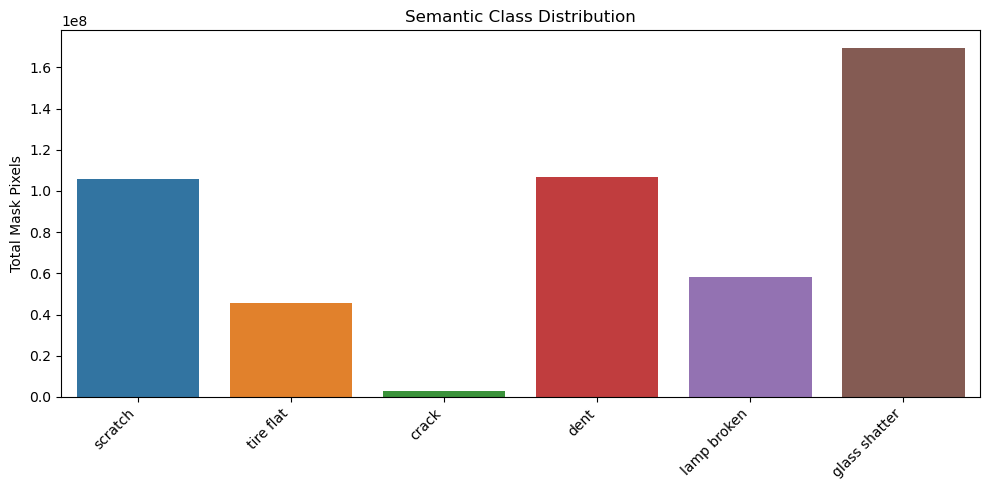

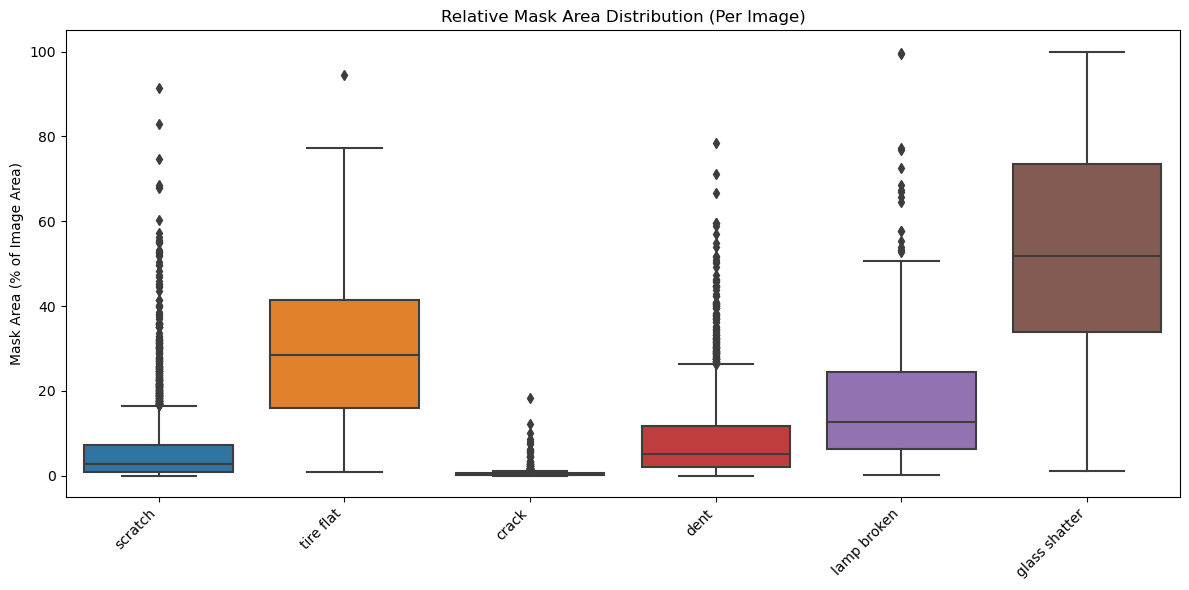

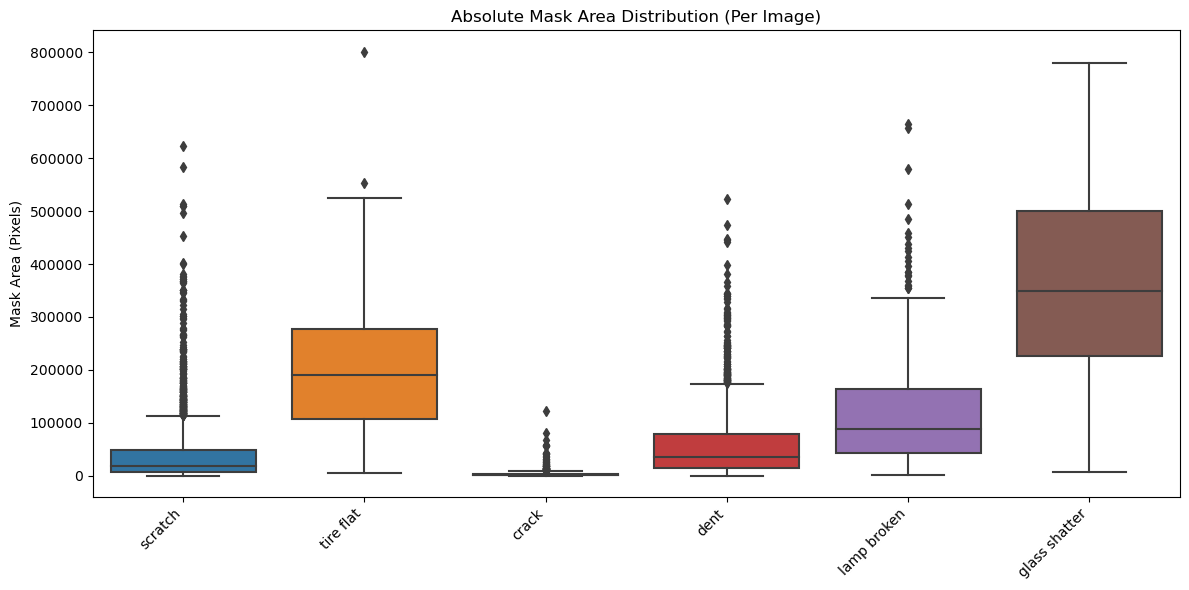

In [8]:
analyze_and_plot_coco_segmentation("/home/akshay/dgx-code/ImageSegmentation/data/CarDD_release/CarDD_COCO/annotations/instances_train2017.json")